# Gold Price Prediction: LSTM & GRU Modeling
## (Feature Engineered + Hyperparameter Tuning)

This notebook builds **LSTM** and **GRU** models for Indonesian gold price prediction with:
- **Engineered Features**: Lag features, rolling statistics, percentage changes
- **Original Features**: USD/IDR exchange rate, inflation, BI-7Day-RR interest rate
- **Target**: Gold price (IDR)
- **Normalization**: MinMaxScaler [0, 1]
- **Split schemes**: 70:30, 80:20, 90:10 (time-based, chronological)
- **Hyperparameter Tuning**: Grid search over units, dropout, learning rate with TimeSeriesSplit CV
- **Validation**: TimeSeriesSplit on training set
- **Evaluation**: RMSE and MAPE

## 1. Import Required Libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import itertools
import time
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version     : {np.__version__}")
print(f"Pandas version    : {pd.__version__}")

TensorFlow version: 2.19.0
NumPy version     : 2.0.2
Pandas version    : 2.2.2


## 2. Load and Preprocess Dataset

In [36]:
df = pd.read_csv('dataset_final.csv', parse_dates=['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
df.head(10)

Shape: (3926, 4)
Date range: 2015-01-01 00:00:00 → 2025-09-30 00:00:00

Missing values:
gold_price       0
usd_idr          0
inflation        0
interest_rate    0
dtype: int64

Data types:
gold_price         int64
usd_idr          float64
inflation        float64
interest_rate    float64
dtype: object


,gold_price,usd_idr,inflation,interest_rate
date,,,,
2015-01-01,549000,12385.0,0.0696,0.0775
2015-01-02,545000,12542.5,0.0696,0.0775
2015-01-03,545000,12542.5,0.0696,0.0775
2015-01-04,545000,12542.5,0.0696,0.0775
2015-01-05,545000,12627.5,0.0696,0.0775
2015-01-06,550000,12657.5,0.0696,0.0775
2015-01-07,557000,12738.5,0.0696,0.0775
2015-01-08,558000,12680.0,0.0696,0.0775
2015-01-09,557000,12651.5,0.0696,0.0775


## 3. Feature Engineering

Create additional features to capture temporal patterns and trends:
1. **Lag Features** — past values of gold price and USD/IDR
2. **Rolling Window Statistics** — moving averages and rolling standard deviation
3. **Percentage Change / Returns** — rate of change over different horizons

### 3.1 Lag Features

In [37]:
# Gold price lag features
for lag in [1, 7, 14]:
    df[f'gold_price_lag_{lag}'] = df['gold_price'].shift(lag)

# USD/IDR lag features
for lag in [1, 7]:
    df[f'usd_idr_lag_{lag}'] = df['usd_idr'].shift(lag)

print("Lag features created:")
print([col for col in df.columns if 'lag' in col])

Lag features created:
['gold_price_lag_1', 'gold_price_lag_7', 'gold_price_lag_14', 'usd_idr_lag_1', 'usd_idr_lag_7']


### 3.2 Rolling Window Statistics (Moving Average & Standard Deviation)

In [38]:
# Gold price rolling statistics
for window in [7, 14, 30]:
    df[f'gold_price_ma_{window}'] = df['gold_price'].rolling(window=window).mean()

for window in [7, 14]:
    df[f'gold_price_std_{window}'] = df['gold_price'].rolling(window=window).std()

# USD/IDR rolling statistics
df['usd_idr_ma_7'] = df['usd_idr'].rolling(window=7).mean()
df['usd_idr_std_7'] = df['usd_idr'].rolling(window=7).std()

print("Rolling features created:")
print([col for col in df.columns if 'ma_' in col or 'std_' in col])

Rolling features created:
['gold_price_ma_7', 'gold_price_ma_14', 'gold_price_ma_30', 'gold_price_std_7', 'gold_price_std_14', 'usd_idr_ma_7', 'usd_idr_std_7']


### 3.3 Percentage Change / Returns

In [39]:
# Gold price percentage change
for period in [1, 7]:
    df[f'gold_price_pct_{period}'] = df['gold_price'].pct_change(periods=period)

# USD/IDR percentage change
for period in [1, 7]:
    df[f'usd_idr_pct_{period}'] = df['usd_idr'].pct_change(periods=period)

print("Percentage change features created:")
print([col for col in df.columns if 'pct_' in col])

Percentage change features created:
['gold_price_pct_1', 'gold_price_pct_7', 'usd_idr_pct_1', 'usd_idr_pct_7']


### 3.4 Drop NaN Rows (from lag/rolling operations)

In [40]:
rows_before = len(df)
df.dropna(inplace=True)
rows_after = len(df)

print(f"Rows before dropping NaN: {rows_before:,}")
print(f"Rows after  dropping NaN: {rows_after:,}")
print(f"Rows dropped: {rows_before - rows_after:,}")
print(f"\nRemaining NaN values: {df.isnull().sum().sum()}")
print(f"Date range: {df.index.min()} → {df.index.max()}")

Rows before dropping NaN: 3,926
Rows after  dropping NaN: 3,897
Rows dropped: 29

Remaining NaN values: 0
Date range: 2015-01-30 00:00:00 → 2025-09-30 00:00:00


### 3.5 Feature Overview & Correlation Heatmap

In [41]:
print(f"Total features available: {len(df.columns) - 1}")
print(f"Columns: {list(df.columns)}\n")
df.describe().round(4)

Total features available: 19
Columns: ['gold_price', 'usd_idr', 'inflation', 'interest_rate', 'gold_price_lag_1', 'gold_price_lag_7', 'gold_price_lag_14', 'usd_idr_lag_1', 'usd_idr_lag_7', 'gold_price_ma_7', 'gold_price_ma_14', 'gold_price_ma_30', 'gold_price_std_7', 'gold_price_std_14', 'usd_idr_ma_7', 'usd_idr_std_7', 'gold_price_pct_1', 'gold_price_pct_7', 'usd_idr_pct_1', 'usd_idr_pct_7']



,gold_price,usd_idr,inflation,interest_rate,gold_price_lag_1,gold_price_lag_7,gold_price_lag_14,usd_idr_lag_1,usd_idr_lag_7,gold_price_ma_7,gold_price_ma_14,gold_price_ma_30,gold_price_std_7,gold_price_std_14,usd_idr_ma_7,usd_idr_std_7,gold_price_pct_1,gold_price_pct_7,usd_idr_pct_1,usd_idr_pct_7
count,3.897000e+03,3897.0000,3897.0000,3897.0000,3.897000e+03,3.897000e+03,3.897000e+03,3897.0000,3897.0000,3.897000e+03,3.897000e+03,3.897000e+03,3897.0000,3897.0000,3897.0000,3897.0000,3897.0000,3897.0000,3897.0000,3897.0000
mean,9.162220e+05,14476.9027,0.0322,0.0521,9.157970e+05,9.133272e+05,9.105627e+05,14475.8513,14469.3373,9.149717e+05,9.135534e+05,9.103924e+05,5424.7702,7431.4388,14473.6782,42.5970,0.0004,0.0025,0.0001,0.0006
std,3.518990e+05,993.5869,0.0148,0.0116,3.513066e+05,3.480091e+05,3.445125e+05,993.4388,992.6215,3.501371e+05,3.482132e+05,3.441392e+05,5261.3500,7139.7278,991.6497,41.3386,0.0059,0.0148,0.0032,0.0099
min,5.610000e+05,12614.5000,-0.0009,0.0350,5.610000e+05,5.610000e+05,5.610000e+05,12567.5000,12472.5000,5.618571e+05,5.625000e+05,5.643333e+05,0.0000,0.0000,12521.7857,0.0000,-0.0338,-0.0502,-0.0323,-0.0835
25%,6.320000e+05,13637.5000,0.0218,0.0425,6.320000e+05,6.310000e+05,6.300000e+05,13637.5000,13635.0000,6.305714e+05,6.305000e+05,6.301667e+05,2225.3946,3172.6856,13628.2143,18.5222,-0.0018,-0.0059,-0.0006,-0.0032
50%,9.180000e+05,14325.0000,0.0313,0.0525,9.180000e+05,9.170000e+05,9.160000e+05,14325.0000,14325.0000,9.188571e+05,9.190000e+05,9.184000e+05,3872.9833,5209.8807,14324.2857,32.4582,0.0000,0.0015,0.0000,0.0007
75%,1.031000e+06,15190.0000,0.0361,0.0600,1.031000e+06,1.030000e+06,1.029000e+06,15190.0000,15185.0000,1.031286e+06,1.030071e+06,1.028133e+06,6626.0669,8999.6947,15191.2143,54.3029,0.0027,0.0095,0.0009,0.0050
max,2.234000e+06,16870.0000,0.0726,0.0775,2.198000e+06,2.164000e+06,2.105000e+06,16870.0000,16870.0000,2.190571e+06,2.154857e+06,2.106233e+06,68785.7266,77564.2945,16847.8571,503.7109,0.0667,0.1457,0.0457,0.1106


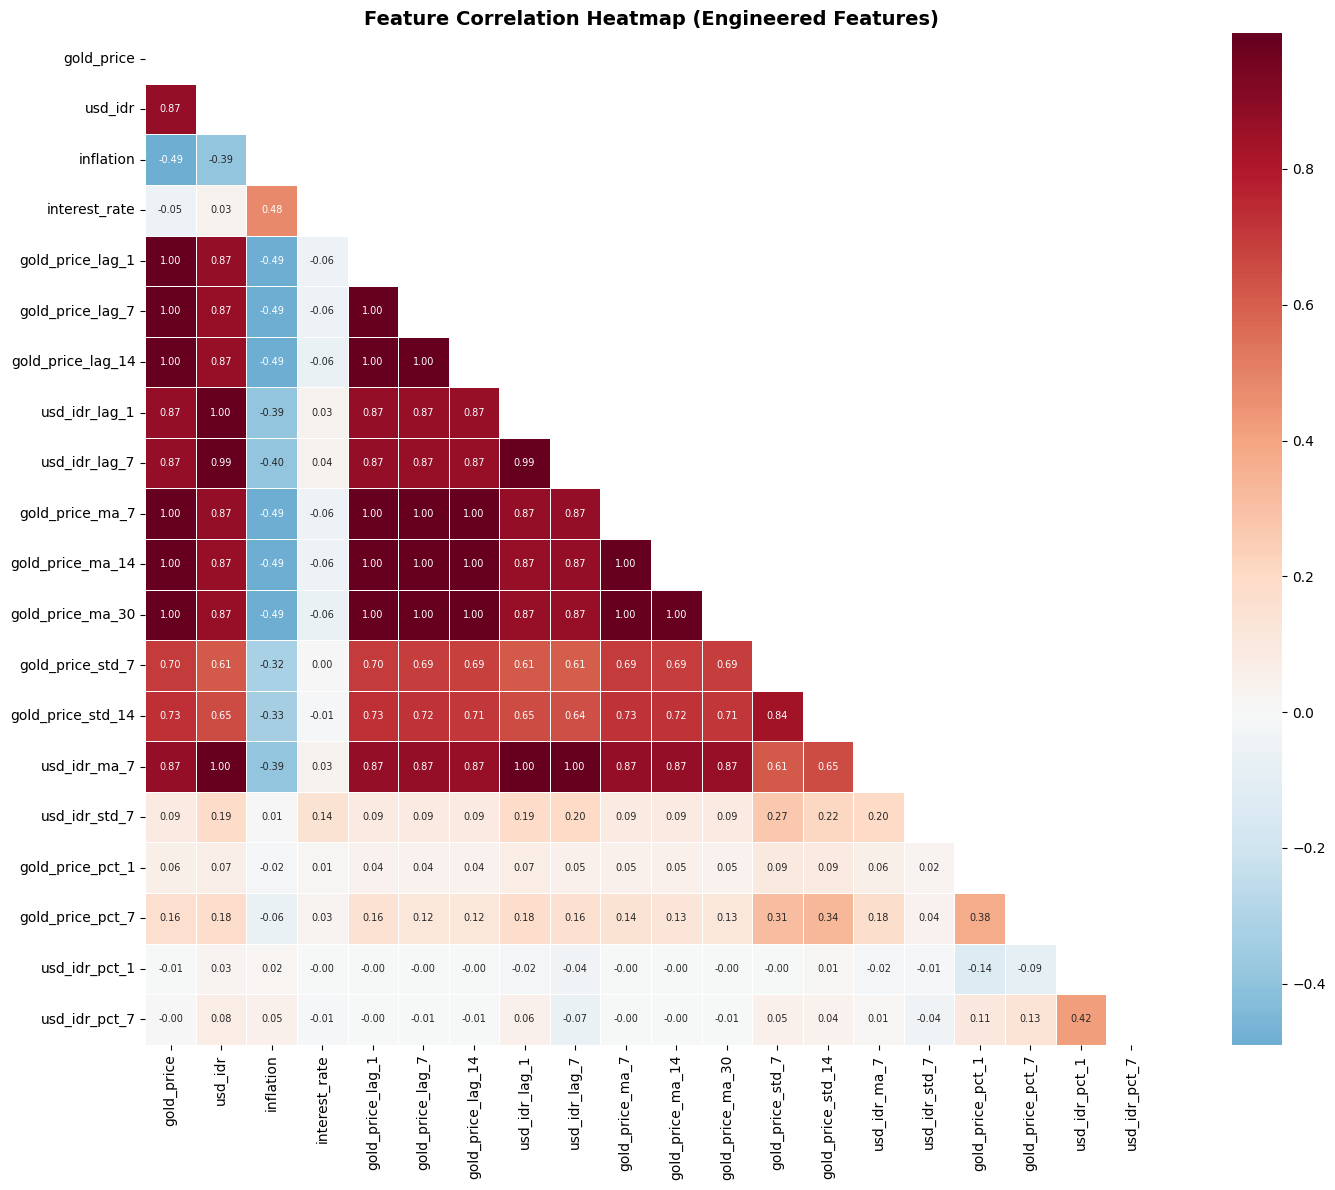

In [42]:
fig, ax = plt.subplots(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap (Engineered Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Define Feature and Target Variables

In [43]:
TARGET = 'gold_price'

FEATURES = [
    # Original features
    'usd_idr', 'inflation', 'interest_rate',
    # Lag features
    'gold_price_lag_1', 'gold_price_lag_7', 'gold_price_lag_14',
    'usd_idr_lag_1', 'usd_idr_lag_7',
    # Rolling statistics
    'gold_price_ma_7', 'gold_price_ma_14', 'gold_price_ma_30',
    'gold_price_std_7', 'gold_price_std_14',
    'usd_idr_ma_7', 'usd_idr_std_7',
    # Percentage changes
    'gold_price_pct_1', 'gold_price_pct_7',
    'usd_idr_pct_1', 'usd_idr_pct_7',
]

X = df[FEATURES].values
y = df[[TARGET]].values

print(f"Features (X) shape: {X.shape}  ({len(FEATURES)} features)")
print(f"Target   (y) shape: {y.shape}")
print(f"\nFeature list ({len(FEATURES)} total):")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")

Features (X) shape: (3897, 19)  (19 features)
Target   (y) shape: (3897, 1)

Feature list (19 total):
   1. usd_idr
   2. inflation
   3. interest_rate
   4. gold_price_lag_1
   5. gold_price_lag_7
   6. gold_price_lag_14
   7. usd_idr_lag_1
   8. usd_idr_lag_7
   9. gold_price_ma_7
  10. gold_price_ma_14
  11. gold_price_ma_30
  12. gold_price_std_7
  13. gold_price_std_14
  14. usd_idr_ma_7
  15. usd_idr_std_7
  16. gold_price_pct_1
  17. gold_price_pct_7
  18. usd_idr_pct_1
  19. usd_idr_pct_7


## 5. Perform Time-Based Splitting (70:30, 80:20, 90:10)

Define train/test splits **before** scaling to establish split indices for each ratio.

In [44]:
SPLIT_RATIOS = {
    '70:30': 0.70,
    '80:20': 0.80,
    '90:10': 0.90,
}

n_samples = len(X)
splits = {}

for name, ratio in SPLIT_RATIOS.items():
    split_idx = int(n_samples * ratio)

    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    splits[name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'split_idx': split_idx,
    }

    print(f"Split {name}: train={X_train.shape[0]:,}  test={X_test.shape[0]:,}  "
          f"(split index={split_idx:,})")

print(f"\nTotal samples: {n_samples:,}")

Split 70:30: train=2,727  test=1,170  (split index=2,727)
Split 80:20: train=3,117  test=780  (split index=3,117)
Split 90:10: train=3,507  test=390  (split index=3,507)

Total samples: 3,897


## 6. Normalize Data Using MinMaxScaler

Fit scalers **only on training data** for each split ratio, then transform both train and test sets using the respective training scalers. This prevents data leakage and applies consistent scaling.

In [45]:
scalers = {}

for split_name in SPLIT_RATIOS.keys():
    data = splits[split_name]
    X_train, X_test = data['X_train'], data['X_test']
    y_train, y_test = data['y_train'], data['y_test']

    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    scaler_X.fit(X_train)
    scaler_y.fit(y_train)

    X_train_scaled = scaler_X.transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.transform(y_train)
    y_test_scaled = scaler_y.transform(y_test)

    splits[split_name].update({
        'X_train_scaled': X_train_scaled,
        'X_test_scaled': X_test_scaled,
        'y_train_scaled': y_train_scaled,
        'y_test_scaled': y_test_scaled,
    })
    scalers[split_name] = {'scaler_X': scaler_X, 'scaler_y': scaler_y}

    print(f"\n{split_name} Split:")
    print(f"  X_train_scaled range: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")
    print(f"  X_test_scaled range:  [{X_test_scaled.min():.4f}, {X_test_scaled.max():.4f}]")
    print(f"  y_train_scaled range: [{y_train_scaled.min():.4f}, {y_train_scaled.max():.4f}]")
    print(f"  y_test_scaled range:  [{y_test_scaled.min():.4f}, {y_test_scaled.max():.4f}]")


70:30 Split:
  X_train_scaled range: [0.0000, 1.0000]
  X_test_scaled range:  [-0.2374, 3.3008]
  y_train_scaled range: [0.0000, 1.0000]
  y_test_scaled range:  [0.7321, 3.3194]

80:20 Split:
  X_train_scaled range: [0.0000, 1.0000]
  X_test_scaled range:  [-0.2374, 3.1032]
  y_train_scaled range: [0.0000, 1.0000]
  y_test_scaled range:  [0.8935, 3.1271]

90:10 Split:
  X_train_scaled range: [0.0000, 1.0000]
  X_test_scaled range:  [-0.2374, 1.8901]
  y_train_scaled range: [0.0000, 1.0000]
  y_test_scaled range:  [0.9599, 1.9186]


## 7. Create Sequences for Time Series Input

In [46]:
LOOKBACK = 60

def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i, 0])
    return np.array(Xs), np.array(ys)

for split_name in SPLIT_RATIOS.keys():
    data = splits[split_name]
    X_train_scaled = data['X_train_scaled']
    X_test_scaled = data['X_test_scaled']
    y_train_scaled = data['y_train_scaled']
    y_test_scaled = data['y_test_scaled']

    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, LOOKBACK)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, LOOKBACK)

    splits[split_name].update({
        'X_train_seq': X_train_seq,
        'X_test_seq': X_test_seq,
        'y_train_seq': y_train_seq,
        'y_test_seq': y_test_seq,
    })

    print(f"{split_name} Sequences:")
    print(f"  X_train_seq: {X_train_seq.shape}")
    print(f"  X_test_seq:  {X_test_seq.shape}")
    print(f"  y_train_seq: {y_train_seq.shape}")
    print(f"  y_test_seq:  {y_test_seq.shape}\n")

70:30 Sequences:
  X_train_seq: (2667, 60, 19)
  X_test_seq:  (1110, 60, 19)
  y_train_seq: (2667,)
  y_test_seq:  (1110,)

80:20 Sequences:
  X_train_seq: (3057, 60, 19)
  X_test_seq:  (720, 60, 19)
  y_train_seq: (3057,)
  y_test_seq:  (720,)

90:10 Sequences:
  X_train_seq: (3447, 60, 19)
  X_test_seq:  (330, 60, 19)
  y_train_seq: (3447,)
  y_test_seq:  (330,)



## 8. Define Hyperparameter Search Space

We perform a **grid search** over the following hyperparameters using TimeSeriesSplit cross-validation on the training set. The best configuration is selected based on the lowest average validation loss.

| Hyperparameter   | Search Space          |
|------------------|-----------------------|
| Units (per layer)| 64, 128, 256          |
| Dropout Rate     | 0.0, 0.05, 0.1        |
| Learning Rate    | 0.0001, 0.0005, 0.001 |

In [47]:
PARAM_GRID = {
    "units": [64, 128, 256],
    "dropout_rate": [0.0, 0.05, 0.1],
    "learning_rate": [0.0001, 0.0005, 0.001],
}

# Generate all combinations
param_keys = list(PARAM_GRID.keys())
param_combos = list(itertools.product(*PARAM_GRID.values()))

print(f"Hyperparameter search space:")
for key, values in PARAM_GRID.items():
    print(f"  {key}: {values}")
print(f"\nTotal combinations per model per split: {len(param_combos)}")
print(f"Total tuning runs: {len(param_combos)} × 2 models × 3 splits = {len(param_combos) * 6}")

Hyperparameter search space:
  units: [64, 128, 256]
  dropout_rate: [0.0, 0.05, 0.1]
  learning_rate: [0.0001, 0.0005, 0.001]

Total combinations per model per split: 27
Total tuning runs: 27 × 2 models × 3 splits = 162


## 9. Build LSTM Model Architecture (Parameterized)

In [48]:
def build_lstm(input_shape, units=128, dropout_rate=0.0, learning_rate=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        LSTM(units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

_tmp = build_lstm((LOOKBACK, len(FEATURES)))
_tmp.summary()
del _tmp

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │        75,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,521 (826.25 KB)

 Trainable params: 211,521 (826.25 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Build GRU Model Architecture (Parameterized)

In [49]:
def build_gru(input_shape, units=128, dropout_rate=0.0, learning_rate=0.001):
    model = Sequential([
        GRU(units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        GRU(units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

_tmp = build_gru((LOOKBACK, len(FEATURES)))
_tmp.summary()
del _tmp

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 128)        │        57,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,449 (626.75 KB)

 Trainable params: 160,449 (626.75 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Hyperparameter Tuning Function

For each model type and split ratio, iterate through all hyperparameter combinations. Each configuration is evaluated using **TimeSeriesSplit** (3-fold) cross-validation on the training set with early stopping. The best configuration is selected by lowest average validation loss.

In [50]:
TUNING_EPOCHS = 50       # Reduced epochs for tuning phase
TUNING_BATCH_SIZE = 32
TUNING_PATIENCE = 5      # Faster early stopping during tuning
TUNING_CV_SPLITS = 3     # TimeSeriesSplit folds for tuning


def tune_hyperparameters(model_builder, split_name, model_name):
    """Grid search over hyperparameter combinations using TimeSeriesSplit CV."""
    data = splits[split_name]
    X_train_seq = data['X_train_seq']
    y_train_seq = data['y_train_seq']

    input_shape = (LOOKBACK, len(FEATURES))
    tscv = TimeSeriesSplit(n_splits=TUNING_CV_SPLITS)

    print(f"{'='*65}")
    print(f"  Tuning {model_name} — Split {split_name}")
    print(f"  Combinations: {len(param_combos)} | CV Folds: {TUNING_CV_SPLITS}")
    print(f"{'='*65}")

    best_val_loss = float('inf')
    best_params = None
    tuning_log = []

    for idx, combo in enumerate(param_combos, 1):
        params = dict(zip(param_keys, combo))
        fold_losses = []

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_seq)):
            X_tr, X_val = X_train_seq[train_idx], X_train_seq[val_idx]
            y_tr, y_val = y_train_seq[train_idx], y_train_seq[val_idx]

            tf.keras.backend.clear_session()
            model = model_builder(
                input_shape=input_shape,
                units=params['units'],
                dropout_rate=params['dropout_rate'],
                learning_rate=params['learning_rate'],
            )

            early_stop = EarlyStopping(
                monitor='val_loss', patience=TUNING_PATIENCE,
                restore_best_weights=True, verbose=0
            )

            model.fit(
                X_tr, y_tr,
                validation_data=(X_val, y_val),
                epochs=TUNING_EPOCHS,
                batch_size=TUNING_BATCH_SIZE,
                callbacks=[early_stop],
                verbose=0,
            )

            val_loss = model.evaluate(X_val, y_val, verbose=0)
            fold_losses.append(val_loss)

        avg_val_loss = np.mean(fold_losses)
        tuning_log.append({**params, 'avg_val_loss': avg_val_loss})

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_params = params.copy()

        print(f"  [{idx:2d}/{len(param_combos)}] "
              f"units={params['units']:3d}  dropout={params['dropout_rate']:.1f}  "
              f"lr={params['learning_rate']:.4f}  → avg_val_loss={avg_val_loss:.6f}"
              f"{'  ★ BEST' if avg_val_loss == best_val_loss else ''}")

    print(f"\n  ✓ Best params: {best_params}")
    print(f"  ✓ Best avg val loss: {best_val_loss:.6f}\n")

    return best_params, pd.DataFrame(tuning_log)

print("Tuning function defined.")

Tuning function defined.


## 12. Run Hyperparameter Tuning for All Model-Split Combinations

In [51]:
best_hyperparams = {}
tuning_logs = {}

for model_name, model_builder in [('LSTM', build_lstm), ('GRU', build_gru)]:
    for split_name in SPLIT_RATIOS.keys():
        key = (model_name, split_name)
        start_time = time.time()

        best_params, log_df = tune_hyperparameters(model_builder, split_name, model_name)

        elapsed = time.time() - start_time
        print(f"  ⏱ Tuning time: {elapsed/60:.1f} min\n")

        best_hyperparams[key] = best_params
        tuning_logs[key] = log_df

  Tuning LSTM — Split 70:30
  Combinations: 27 | CV Folds: 3
  [ 1/27] units= 64  dropout=0.0  lr=0.0001  → avg_val_loss=0.001932  ★ BEST
  [ 2/27] units= 64  dropout=0.0  lr=0.0005  → avg_val_loss=0.009814
  [ 3/27] units= 64  dropout=0.0  lr=0.0010  → avg_val_loss=0.003434
  [ 4/27] units= 64  dropout=0.1  lr=0.0001  → avg_val_loss=0.005406
  [ 5/27] units= 64  dropout=0.1  lr=0.0005  → avg_val_loss=0.001741  ★ BEST
  [ 6/27] units= 64  dropout=0.1  lr=0.0010  → avg_val_loss=0.003320
  [ 7/27] units= 64  dropout=0.1  lr=0.0001  → avg_val_loss=0.005218
  [ 8/27] units= 64  dropout=0.1  lr=0.0005  → avg_val_loss=0.002308
  [ 9/27] units= 64  dropout=0.1  lr=0.0010  → avg_val_loss=0.001074  ★ BEST
  [10/27] units=128  dropout=0.0  lr=0.0001  → avg_val_loss=0.008418
  [11/27] units=128  dropout=0.0  lr=0.0005  → avg_val_loss=0.001921
  [12/27] units=128  dropout=0.0  lr=0.0010  → avg_val_loss=0.005196
  [13/27] units=128  dropout=0.1  lr=0.0001  → avg_val_loss=0.004218
  [14/27] units=12

### 12.1 Hyperparameter Tuning Summary

In [52]:
hp_summary_rows = []
for (model_name, split_name), params in best_hyperparams.items():
    hp_summary_rows.append({
        'Model': model_name,
        'Split': split_name,
        'Units': params['units'],
        'Dropout': params['dropout_rate'],
        'Learning Rate': params['learning_rate'],
    })

df_hp_summary = pd.DataFrame(hp_summary_rows)
print("=" * 65)
print("  BEST HYPERPARAMETERS PER MODEL-SPLIT COMBINATION")
print("=" * 65)
df_hp_summary

  BEST HYPERPARAMETERS PER MODEL-SPLIT COMBINATION


,Model,Split,Units,Dropout,Learning Rate
0,LSTM,70:30,256,0.05,0.0005
1,LSTM,80:20,256,0.00,0.0005
2,LSTM,90:10,256,0.00,0.0010
3,GRU,70:30,256,0.05,0.0010
4,GRU,80:20,256,0.10,0.0010
5,GRU,90:10,256,0.00,0.0010


## 13. Helper: Training & Plotting Functions

Reusable utilities for training a model **with the best hyperparameters** found during tuning, using `TimeSeriesSplit` validation and plotting results.

In [53]:
def calc_rmse(y_true, y_pred):
    """Root Mean Squared Error on original scale."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def calc_mape(y_true, y_pred):
    """Mean Absolute Percentage Error (×100 → %)."""
    return mean_absolute_percentage_error(y_true, y_pred) * 100

EPOCHS = 200
BATCH_SIZE = 32


def train_and_evaluate(model_builder, split_name, model_name):
    """Train with best hyperparameters and evaluate on test set."""
    data = splits[split_name]
    X_train_seq = data['X_train_seq']
    X_test_seq = data['X_test_seq']
    y_train_seq = data['y_train_seq']
    y_test_seq = data['y_test_seq']
    scaler_y = scalers[split_name]['scaler_y']

    # Retrieve best hyperparameters from tuning
    key = (model_name, split_name)
    params = best_hyperparams[key]

    # Use last fold of TimeSeriesSplit for validation during final training
    tscv = TimeSeriesSplit(n_splits=5)
    for train_idx, val_idx in tscv.split(X_train_seq):
        pass
    X_tr, X_val = X_train_seq[train_idx], X_train_seq[val_idx]
    y_tr, y_val = y_train_seq[train_idx], y_train_seq[val_idx]

    print(f"{'='*65}")
    print(f"  {model_name} — Split {split_name} (Best Hyperparameters)")
    print(f"  units={params['units']}  dropout={params['dropout_rate']}  lr={params['learning_rate']}")
    print(f"  Train: {X_tr.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test_seq.shape[0]:,}")
    print(f"{'='*65}")

    tf.keras.backend.clear_session()
    model = model_builder(
        input_shape=(LOOKBACK, len(FEATURES)),
        units=params['units'],
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate'],
    )

    early_stop = EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
    )

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1,
    )

    y_pred_scaled = model.predict(X_test_seq, verbose=0).flatten()

    y_test_inv = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
    y_pred_inv = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    rmse = calc_rmse(y_test_inv, y_pred_inv)
    mape = calc_mape(y_test_inv, y_pred_inv)
    print(f"\n  ► RMSE : Rp {rmse:,.0f}")
    print(f"  ► MAPE : {mape:.2f}%\n")

    return {
        'model': model,
        'history': history,
        'y_test_inv': y_test_inv,
        'y_pred_inv': y_pred_inv,
        'rmse': rmse,
        'mape': mape,
        'best_params': params,
    }


def plot_loss(history, model_name, split_name):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history['loss'], label='Training Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')
    ax.set_title(f'{model_name} — Split {split_name} — Loss Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_prediction(y_true, y_pred, model_name, split_name):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(y_true, label='Actual', linewidth=1.2)
    ax.plot(y_pred, label='Predicted', linewidth=1.2, alpha=0.85)
    ax.set_title(f'{model_name} — Split {split_name} — Actual vs Predicted Gold Price')
    ax.set_xlabel('Test Samples')
    ax.set_ylabel('Gold Price (IDR)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


print("Helper functions defined.")

Helper functions defined.


## 14. Train and Predict — LSTM with 70:30 Split

  LSTM — Split 70:30 (Best Hyperparameters)
  units=256  dropout=0.05  lr=0.0005
  Train: 2,223  Val: 444  Test: 1,110
Epoch 1/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0271 - val_loss: 0.0011
Epoch 2/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.3954e-04 - val_loss: 0.0011
Epoch 3/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.2026e-04 - val_loss: 0.0016
Epoch 4/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.5063e-04 - val_loss: 0.0015
Epoch 5/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.5838e-04 - val_loss: 9.0967e-04
Epoch 6/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.6704e-04 - val_loss: 6.6911e-04
Epoch 7/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.1082e-04 - val_loss: 0.0010
Epoch 8/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5253e-04 - val_loss: 0.0015
Epoch 9/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.7910e-04 - val_loss: 9.2112e-04
Epoch 10/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.

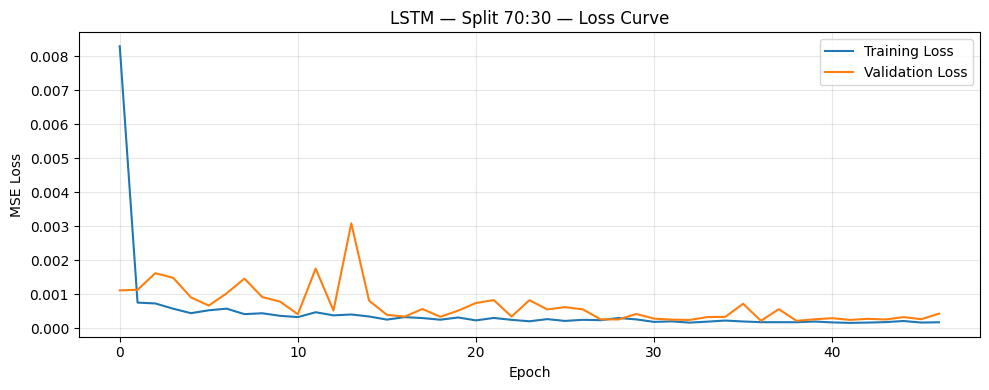

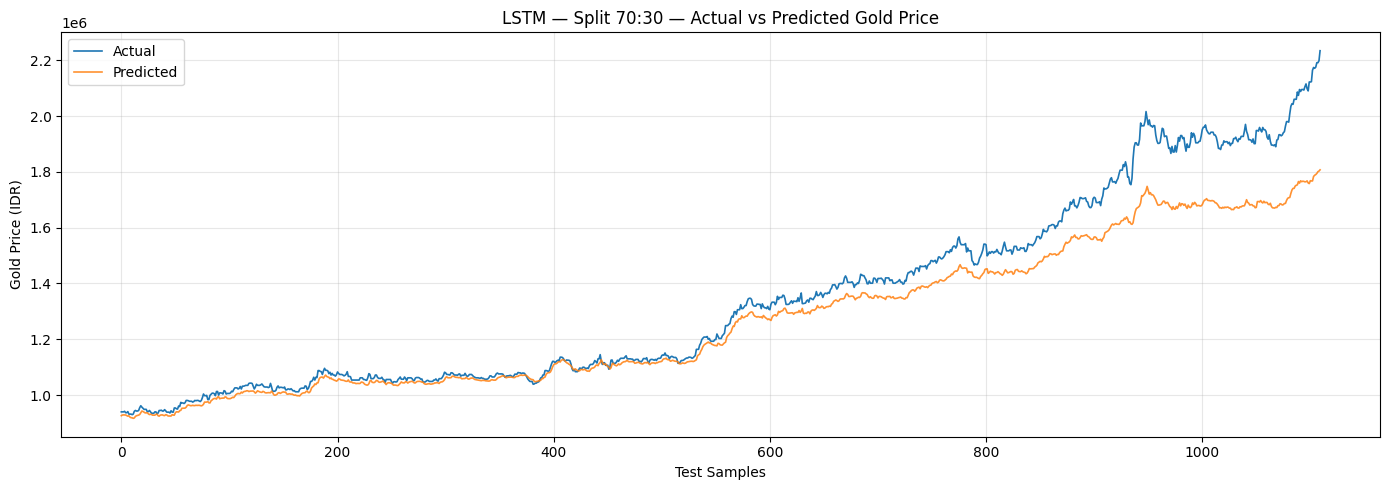

In [54]:
results_lstm_70 = train_and_evaluate(build_lstm, '70:30', 'LSTM')
plot_loss(results_lstm_70['history'], 'LSTM', '70:30')
plot_prediction(results_lstm_70['y_test_inv'], results_lstm_70['y_pred_inv'], 'LSTM', '70:30')

## 15. Train and Predict — LSTM with 80:20 Split

  LSTM — Split 80:20 (Best Hyperparameters)
  units=256  dropout=0.0  lr=0.0005
  Train: 2,548  Val: 509  Test: 720
Epoch 1/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0228 - val_loss: 0.0080
Epoch 2/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7612e-04 - val_loss: 0.0049
Epoch 3/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.4385e-04 - val_loss: 0.0043
Epoch 4/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.6854e-04 - val_loss: 0.0031
Epoch 5/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2343e-04 - val_loss: 0.0023
Epoch 6/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.8308e-04 - val_loss: 0.0017
Epoch 7/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.6173e-04 - val_loss: 0.0012
Epoch 8/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5455e-04 - val_loss: 0.0011
Epoch 9/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4082e-04 - val_loss: 9.8895e-04
Epoch 10/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.2438e-04 - 

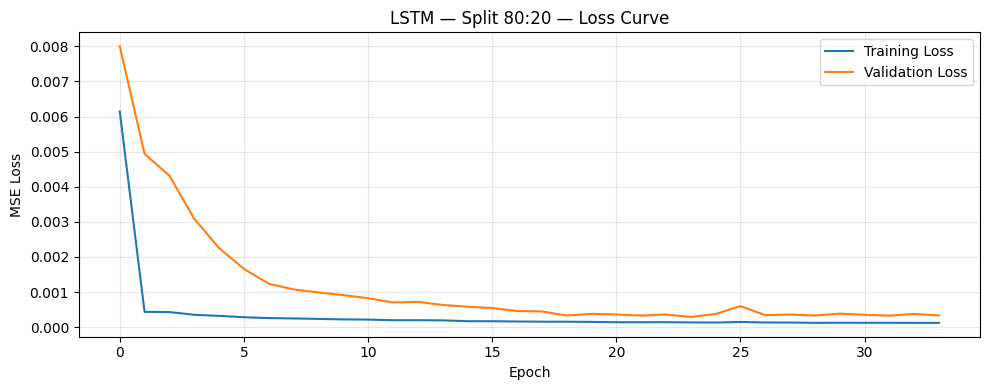

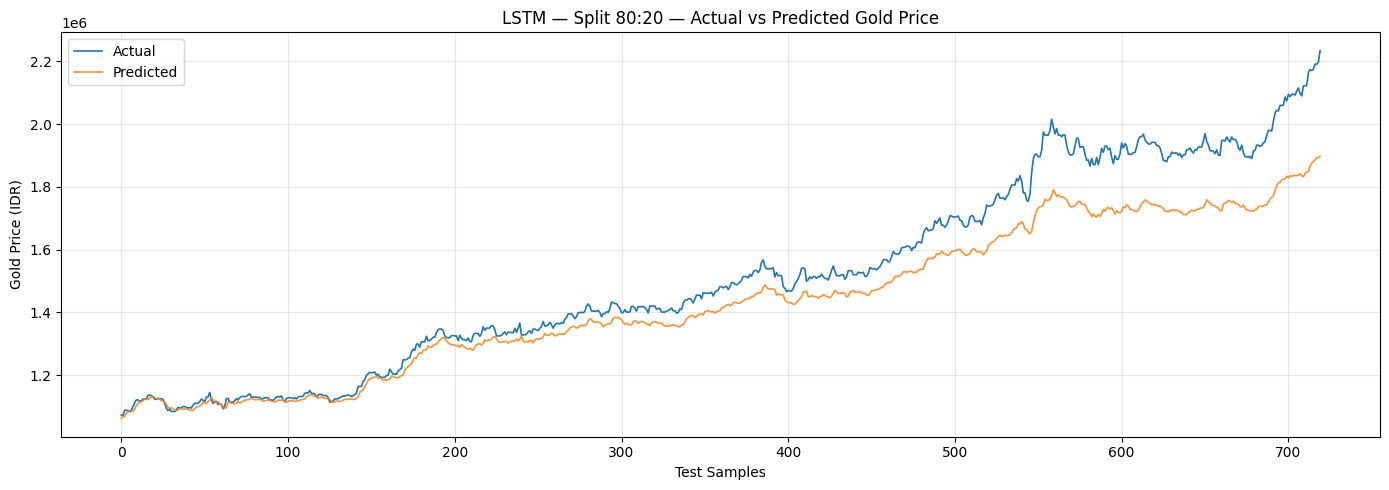

In [55]:
results_lstm_80 = train_and_evaluate(build_lstm, '80:20', 'LSTM')
plot_loss(results_lstm_80['history'], 'LSTM', '80:20')
plot_prediction(results_lstm_80['y_test_inv'], results_lstm_80['y_pred_inv'], 'LSTM', '80:20')

## 16. Train and Predict — LSTM with 90:10 Split

  LSTM — Split 90:10 (Best Hyperparameters)
  units=256  dropout=0.0  lr=0.001
  Train: 2,873  Val: 574  Test: 330
Epoch 1/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0076 - val_loss: 0.0063
Epoch 2/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1687e-04 - val_loss: 0.0051
Epoch 3/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8731e-04 - val_loss: 0.0046
Epoch 4/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5696e-04 - val_loss: 0.0037
Epoch 5/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6362e-04 - val_loss: 0.0040
Epoch 6/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4113e-04 - val_loss: 0.0036
Epoch 7/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2785e-04 - val_loss: 0.0027
Epoch 8/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2128e-04 - val_loss: 0.0026
Epoch 9/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1069e-04 - val_loss: 0.0023
Epoch 10/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0699e-04 - val_l

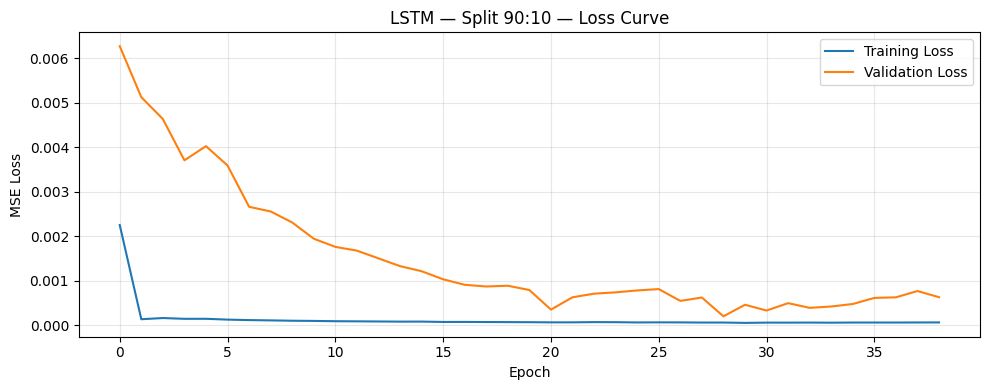

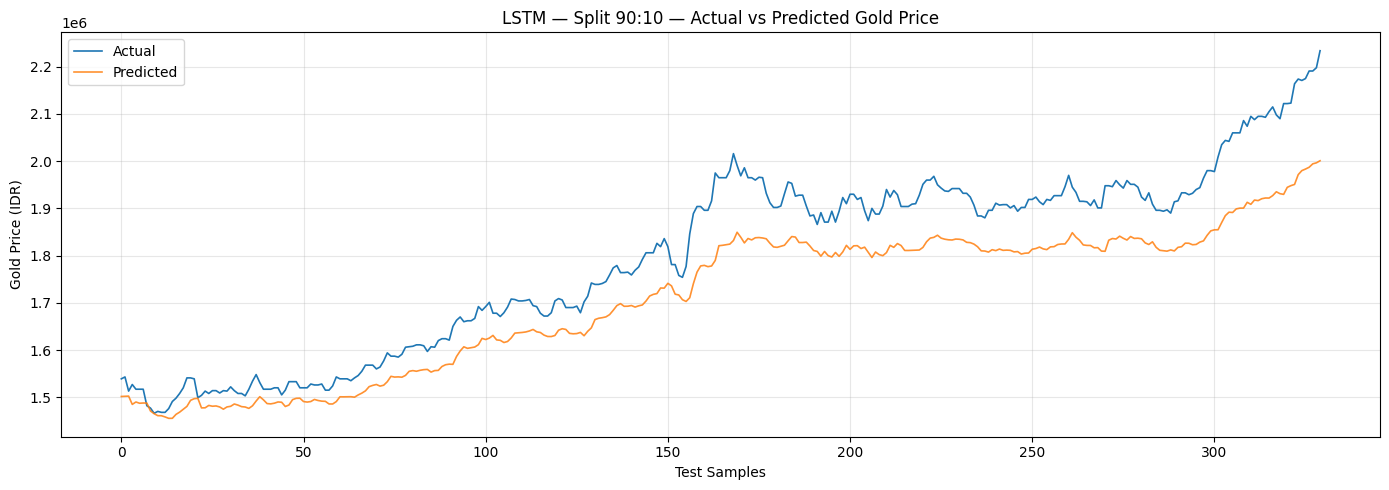

In [56]:
results_lstm_90 = train_and_evaluate(build_lstm, '90:10', 'LSTM')
plot_loss(results_lstm_90['history'], 'LSTM', '90:10')
plot_prediction(results_lstm_90['y_test_inv'], results_lstm_90['y_pred_inv'], 'LSTM', '90:10')

## 17. Train and Predict — GRU with 70:30 Split

  GRU — Split 70:30 (Best Hyperparameters)
  units=256  dropout=0.05  lr=0.001
  Train: 2,223  Val: 444  Test: 1,110
Epoch 1/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0164 - val_loss: 8.2644e-04
Epoch 2/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.0443e-04 - val_loss: 5.0875e-04
Epoch 3/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.9621e-04 - val_loss: 5.3094e-04
Epoch 4/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.6026e-04 - val_loss: 8.8545e-04
Epoch 5/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.2826e-04 - val_loss: 5.2432e-04
Epoch 6/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1992e-04 - val_loss: 3.0498e-04
Epoch 7/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6858e-04 - val_loss: 4.6448e-04
Epoch 8/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.6924e-04 - val_loss: 3.9866e-04
Epoch 9/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.2604e-04 - val_loss: 3.3084e-04
Epoch 10/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1

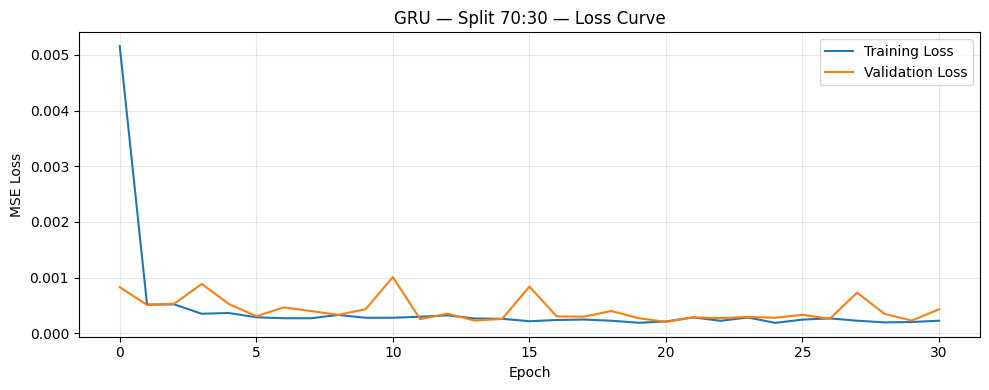

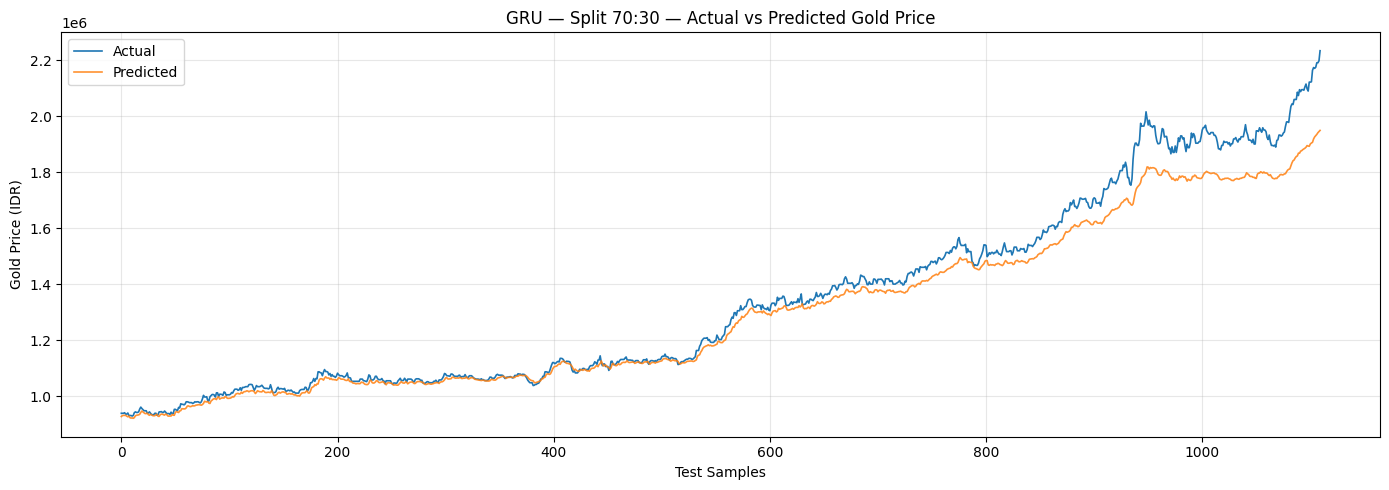

In [57]:
results_gru_70 = train_and_evaluate(build_gru, '70:30', 'GRU')
plot_loss(results_gru_70['history'], 'GRU', '70:30')
plot_prediction(results_gru_70['y_test_inv'], results_gru_70['y_pred_inv'], 'GRU', '70:30')

## 18. Train and Predict — GRU with 80:20 Split

  GRU — Split 80:20 (Best Hyperparameters)
  units=256  dropout=0.1  lr=0.001
  Train: 2,548  Val: 509  Test: 720
Epoch 1/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0168 - val_loss: 0.0030
Epoch 2/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.6157e-04 - val_loss: 0.0023
Epoch 3/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.0834e-04 - val_loss: 0.0022
Epoch 4/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.2708e-04 - val_loss: 0.0013
Epoch 5/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5146e-04 - val_loss: 2.9958e-04
Epoch 6/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3206e-04 - val_loss: 1.9070e-04
Epoch 7/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8861e-04 - val_loss: 2.4662e-04
Epoch 8/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.1377e-04 - val_loss: 0.0015
Epoch 9/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.3208e-04 - val_loss: 7.3737e-04
Epoch 10/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7

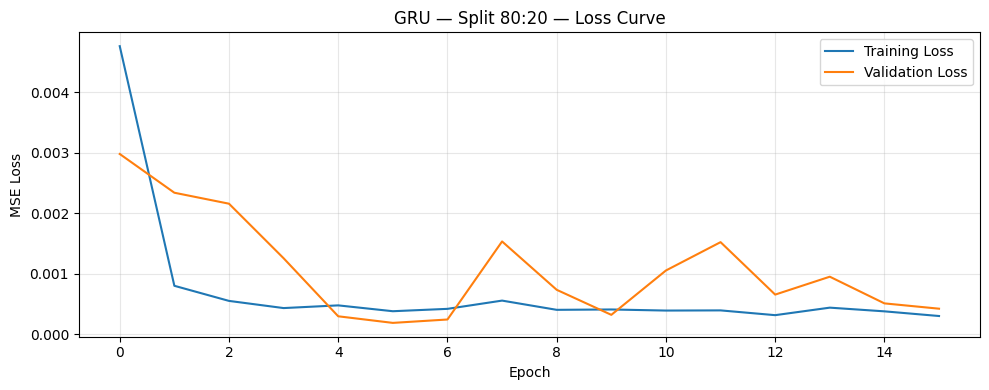

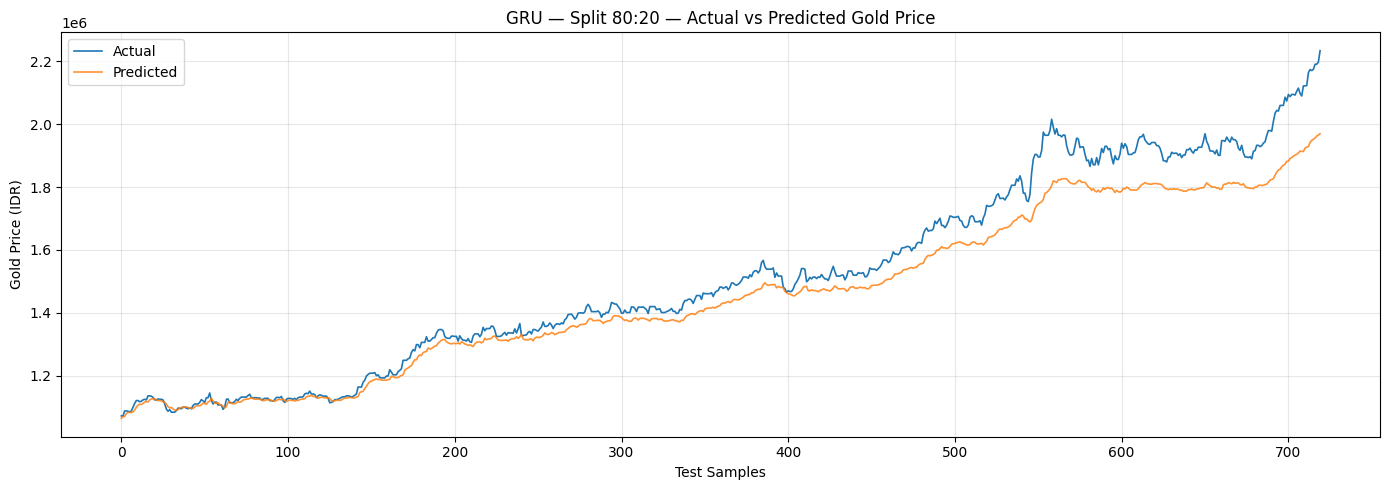

In [58]:
results_gru_80 = train_and_evaluate(build_gru, '80:20', 'GRU')
plot_loss(results_gru_80['history'], 'GRU', '80:20')
plot_prediction(results_gru_80['y_test_inv'], results_gru_80['y_pred_inv'], 'GRU', '80:20')

## 19. Train and Predict — GRU with 90:10 Split

  GRU — Split 90:10 (Best Hyperparameters)
  units=256  dropout=0.0  lr=0.001
  Train: 2,873  Val: 574  Test: 330
Epoch 1/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0109 - val_loss: 0.0016
Epoch 2/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.0477e-05 - val_loss: 0.0023
Epoch 3/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.4008e-05 - val_loss: 0.0016
Epoch 4/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.6820e-05 - val_loss: 7.2862e-04
Epoch 5/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.7208e-05 - val_loss: 2.2982e-04
Epoch 6/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.4908e-05 - val_loss: 3.0722e-04
Epoch 7/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.0481e-05 - val_loss: 3.8362e-04
Epoch 8/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.3936e-05 - val_loss: 1.2872e-04
Epoch 9/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.1767e-05 - val_loss: 1.2301e-04
Epoch 10/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - l

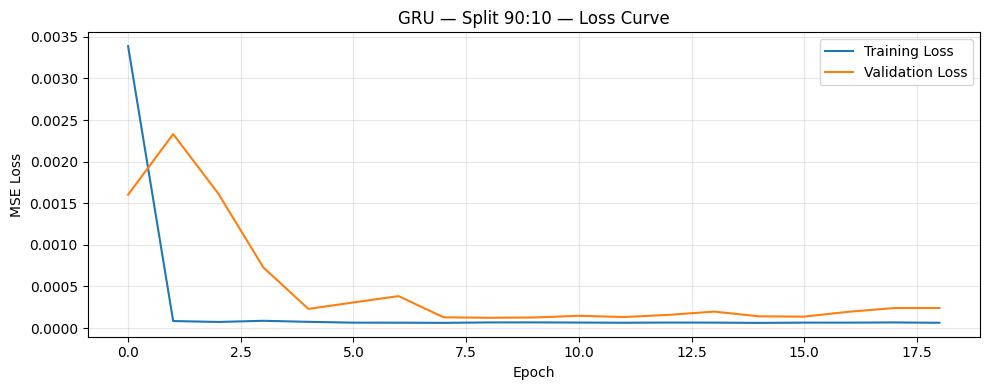

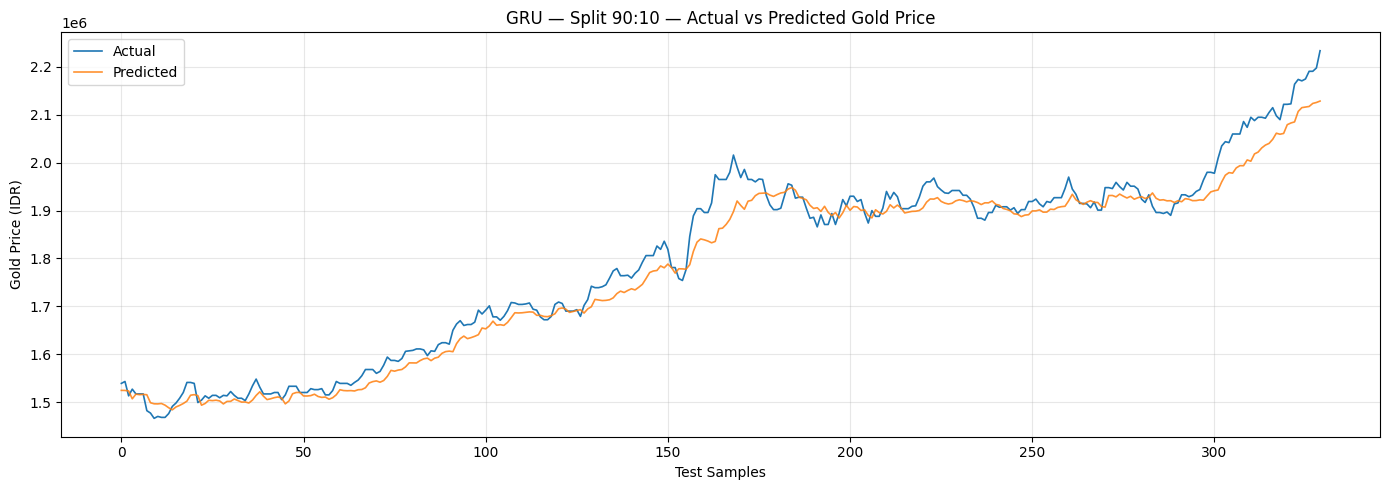

In [59]:
results_gru_90 = train_and_evaluate(build_gru, '90:10', 'GRU')
plot_loss(results_gru_90['history'], 'GRU', '90:10')
plot_prediction(results_gru_90['y_test_inv'], results_gru_90['y_pred_inv'], 'GRU', '90:10')

## 20. Evaluate Models Using RMSE and MAPE

Compile all 6 model-split combinations and compute RMSE (Root Mean Squared Error) and MAPE (Mean Absolute Percentage Error) on the **original scale** (inverse-transformed predictions).

In [60]:
all_results = {
    ('LSTM', '70:30'): results_lstm_70,
    ('LSTM', '80:20'): results_lstm_80,
    ('LSTM', '90:10'): results_lstm_90,
    ('GRU',  '70:30'): results_gru_70,
    ('GRU',  '80:20'): results_gru_80,
    ('GRU',  '90:10'): results_gru_90,
}

eval_rows = []
for (model_name, split_name), res in all_results.items():
    p = res['best_params']
    eval_rows.append({
        'Model': model_name,
        'Split': split_name,
        'Units': p['units'],
        'Dropout': p['dropout_rate'],
        'LR': p['learning_rate'],
        'RMSE (IDR)': res['rmse'],
        'MAPE (%)': res['mape'],
    })

df_eval = pd.DataFrame(eval_rows)
print("=" * 75)
print("EVALUATION SUMMARY — RMSE & MAPE (with Best Hyperparameters)")
print("=" * 75)
df_eval

EVALUATION SUMMARY — RMSE & MAPE (with Best Hyperparameters)


,Model,Split,Units,Dropout,LR,RMSE (IDR),MAPE (%)
0,LSTM,70:30,256,0.05,0.0005,115598.959669,4.462544
1,LSTM,80:20,256,0.00,0.0005,112260.875565,4.739346
2,LSTM,90:10,256,0.00,0.0010,96808.452038,4.576314
3,GRU,70:30,256,0.05,0.0010,70450.403223,2.774941
4,GRU,80:20,256,0.10,0.0010,81062.640318,3.482295
5,GRU,90:10,256,0.00,0.0010,35417.910634,1.466799


## 21. Compare Results Across All Split Schemes

Side-by-side bar charts comparing RMSE and MAPE for LSTM vs GRU across the three split ratios.

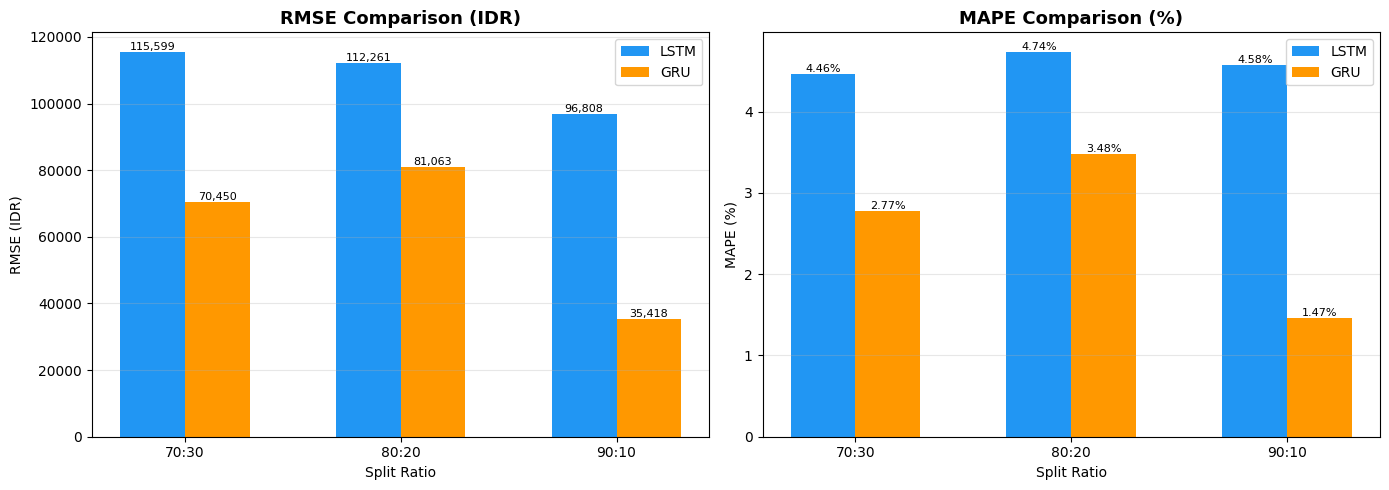

In [61]:
split_labels = ['70:30', '80:20', '90:10']
x = np.arange(len(split_labels))
width = 0.30

lstm_rmse = df_eval[df_eval['Model'] == 'LSTM']['RMSE (IDR)'].values
gru_rmse  = df_eval[df_eval['Model'] == 'GRU']['RMSE (IDR)'].values
lstm_mape = df_eval[df_eval['Model'] == 'LSTM']['MAPE (%)'].values
gru_mape  = df_eval[df_eval['Model'] == 'GRU']['MAPE (%)'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars1 = ax.bar(x - width/2, lstm_rmse, width, label='LSTM', color='#2196F3')
bars2 = ax.bar(x + width/2, gru_rmse,  width, label='GRU',  color='#FF9800')
ax.set_title('RMSE Comparison (IDR)', fontsize=13, fontweight='bold')
ax.set_xlabel('Split Ratio')
ax.set_ylabel('RMSE (IDR)')
ax.set_xticks(x)
ax.set_xticklabels(split_labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

ax = axes[1]
bars1 = ax.bar(x - width/2, lstm_mape, width, label='LSTM', color='#2196F3')
bars2 = ax.bar(x + width/2, gru_mape,  width, label='GRU',  color='#FF9800')
ax.set_title('MAPE Comparison (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Split Ratio')
ax.set_ylabel('MAPE (%)')
ax.set_xticks(x)
ax.set_xticklabels(split_labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
best_rmse_row = df_eval.loc[df_eval['RMSE (IDR)'].idxmin()]
best_mape_row = df_eval.loc[df_eval['MAPE (%)'].idxmin()]

print("=" * 75)
print("  BEST PERFORMING CONFIGURATION")
print("=" * 75)
print(f"\n  Lowest RMSE : {best_rmse_row['Model']} with {best_rmse_row['Split']} split")
print(f"                RMSE = Rp {best_rmse_row['RMSE (IDR)']:,.0f}")
print(f"                Params: units={best_rmse_row['Units']}, dropout={best_rmse_row['Dropout']}, lr={best_rmse_row['LR']}")
print(f"\n  Lowest MAPE : {best_mape_row['Model']} with {best_mape_row['Split']} split")
print(f"                MAPE = {best_mape_row['MAPE (%)']:.2f}%")
print(f"                Params: units={best_mape_row['Units']}, dropout={best_mape_row['Dropout']}, lr={best_mape_row['LR']}")
print("=" * 75)

print("\n\nFull Evaluation Table:")
print(df_eval.to_string(index=False, float_format=lambda x: f'{x:,.4f}'))   

  BEST PERFORMING CONFIGURATION

  Lowest RMSE : GRU with 90:10 split
                RMSE = Rp 35,418
                Params: units=256, dropout=0.0, lr=0.001

  Lowest MAPE : GRU with 90:10 split
                MAPE = 1.47%
                Params: units=256, dropout=0.0, lr=0.001


Full Evaluation Table:
Model Split  Units  Dropout     LR   RMSE (IDR)  MAPE (%)
 LSTM 70:30    256   0.0500 0.0005 115,598.9597    4.4625
 LSTM 80:20    256   0.0000 0.0005 112,260.8756    4.7393
 LSTM 90:10    256   0.0000 0.0010  96,808.4520    4.5763
  GRU 70:30    256   0.0500 0.0010  70,450.4032    2.7749
  GRU 80:20    256   0.1000 0.0010  81,062.6403    3.4823
  GRU 90:10    256   0.0000 0.0010  35,417.9106    1.4668


## 21.1 Prediction vs Actual (Scatter) and Model Comparison Lines

Scatter plots show how close predictions are to actual values. Line chart compares actual vs LSTM/GRU predictions on the same test set split.

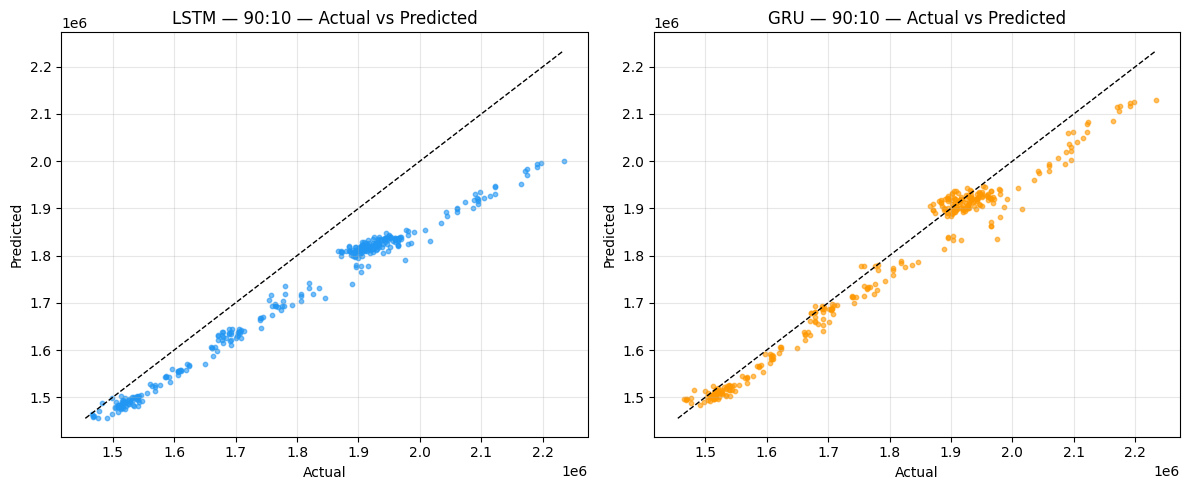

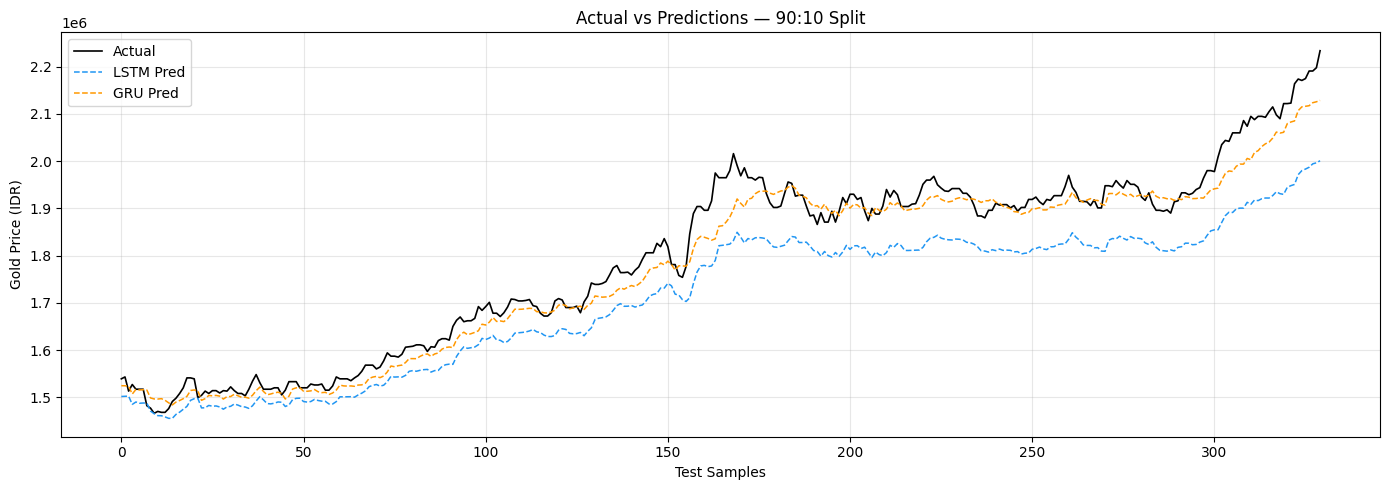

In [63]:
# Compare on the same split (use best MAPE split by default)
compare_split = best_mape_row['Split'] if 'best_mape_row' in globals() else '90:10'
lstm_res = all_results[('LSTM', compare_split)]
gru_res = all_results[('GRU', compare_split)]

y_true = gru_res['y_test_inv']
y_pred_lstm = lstm_res['y_pred_inv']
y_pred_gru = gru_res['y_pred_inv']

# Scatter: actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
min_val = min(y_true.min(), y_pred_lstm.min(), y_pred_gru.min())
max_val = max(y_true.max(), y_pred_lstm.max(), y_pred_gru.max())

axes[0].scatter(y_true, y_pred_lstm, s=10, alpha=0.6, color='#2196F3')
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
axes[0].set_title(f'LSTM — {compare_split} — Actual vs Predicted')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_true, y_pred_gru, s=10, alpha=0.6, color='#FF9800')
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
axes[1].set_title(f'GRU — {compare_split} — Actual vs Predicted')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Line chart: actual vs predictions
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_true, label='Actual', color='black', linewidth=1.2)
ax.plot(y_pred_lstm, label='LSTM Pred', color='#2196F3', linestyle='--', linewidth=1.1)
ax.plot(y_pred_gru, label='GRU Pred', color='#FF9800', linestyle='--', linewidth=1.1)
ax.set_title(f'Actual vs Predictions — {compare_split} Split')
ax.set_xlabel('Test Samples')
ax.set_ylabel('Gold Price (IDR)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
import os
import joblib

# Choose the single best model (lowest MAPE by default)
best_row = best_mape_row if 'best_mape_row' in globals() else None
if best_row is None:
    raise ValueError('best_mape_row is not defined. Run evaluation first.')

best_model_name = best_row['Model']
best_split = best_row['Split']

best_result = all_results[(best_model_name, best_split)]

# Output directory
export_dir = 'saved_models'
os.makedirs(export_dir, exist_ok=True)

# Save Keras model
model_path = os.path.join(
    export_dir,
    f"{best_model_name.lower()}_{best_split.replace(':', '-')}.keras",
)
best_result['model'].save(model_path)

# Save scalers and metadata
scalers_path = os.path.join(export_dir, f"scalers_{best_split.replace(':', '-')}.joblib")
meta_path = os.path.join(export_dir, f"meta_{best_split.replace(':', '-')}.joblib")

joblib.dump(scalers[best_split], scalers_path)
joblib.dump({
    'model': best_model_name,
    'features': FEATURES,
    'target': TARGET,
    'lookback': LOOKBACK,
    'split': best_split,
    'best_params': best_result['best_params'],
}, meta_path)

print('Saved files:')
print(' -', model_path)
print(' -', scalers_path)
print(' -', meta_path)

Saved files:
 - saved_models/gru_90-10.keras
 - saved_models/scalers_90-10.joblib
 - saved_models/meta_90-10.joblib


## 22. Hyperparameter Tuning Details

Display the full tuning log for each model-split combination, showing all hyperparameter combinations tested and their average validation losses.

In [64]:
for (model_name, split_name), log_df in tuning_logs.items():
    print(f"\n{'='*65}")
    print(f"  {model_name} — Split {split_name} — Tuning Log")
    print(f"{'='*65}")
    log_sorted = log_df.sort_values('avg_val_loss').reset_index(drop=True)
    log_sorted.index += 1
    log_sorted.index.name = 'Rank'
    print(log_sorted.to_string(float_format=lambda x: f'{x:.6f}'))
    print()


  LSTM — Split 70:30 — Tuning Log
      units  dropout_rate  learning_rate  avg_val_loss
Rank                                                  
1       256      0.050000       0.000500      0.000733
2       256      0.000000       0.000500      0.000770
3        64      0.100000       0.001000      0.001074
4       128      0.050000       0.000500      0.001185
5       256      0.100000       0.001000      0.001276
6       256      0.100000       0.000500      0.001362
7       256      0.000000       0.000100      0.001467
8       256      0.100000       0.000100      0.001518
9       256      0.050000       0.001000      0.001618
10      128      0.100000       0.000500      0.001658
11       64      0.050000       0.000500      0.001741
12      128      0.100000       0.000100      0.001790
13      128      0.000000       0.000500      0.001921
14       64      0.000000       0.000100      0.001932
15      256      0.050000       0.000100      0.002071
16      128      0.100000     

### 22.1 Visualize Tuning Results — Heatmaps

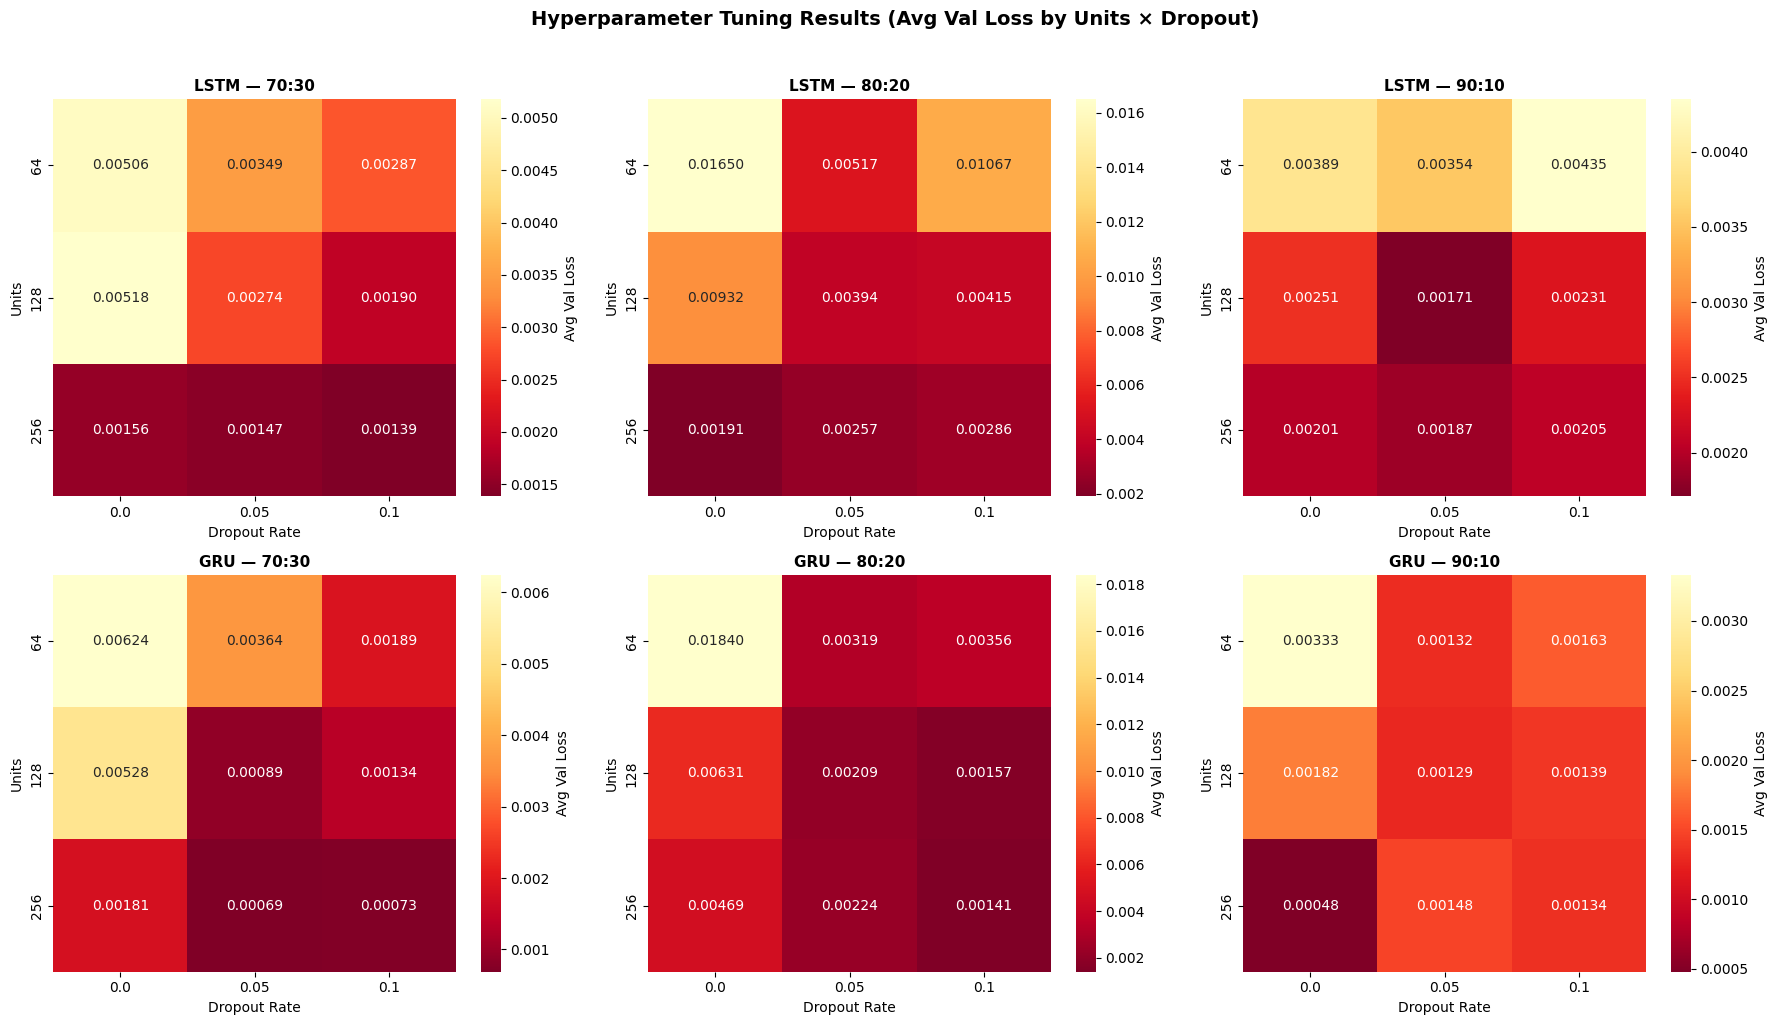

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, ((model_name, split_name), log_df) in enumerate(tuning_logs.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    # Aggregate: for each (units, dropout_rate), average over learning rates
    pivot = log_df.groupby(['units', 'dropout_rate'])['avg_val_loss'].mean().unstack()
    sns.heatmap(pivot, annot=True, fmt='.5f', cmap='YlOrRd_r', ax=ax,
                cbar_kws={'label': 'Avg Val Loss'})
    ax.set_title(f'{model_name} — {split_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Dropout Rate')
    ax.set_ylabel('Units')

plt.suptitle('Hyperparameter Tuning Results (Avg Val Loss by Units × Dropout)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [67]:
!zip -r /content/file.zip /content/saved_models

  adding: content/saved_models/ (stored 0%)
  adding: content/saved_models/meta_90-10.joblib (deflated 47%)
  adding: content/saved_models/gru_90-10.keras (deflated 6%)
  adding: content/saved_models/scalers_90-10.joblib (deflated 39%)
